In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

df = pd.read_csv("ecommerce_data.csv")

df.head()


,Order_ID,Customer_ID,Date,Age,Gender,City,Product_Category,Unit_Price,Quantity,Discount_Amount,Total_Amount,Payment_Method,Device_Type,Session_Duration_Minutes,Pages_Viewed,Is_Returning_Customer,Delivery_Time_Days,Customer_Rating
0,ORD_000001-1,CUST_00001,2023-05-29,40,Male,Ankara,Books,29.18,1,0.00,29.18,Digital Wallet,Mobile,14,9,True,13,4
1,ORD_000001-2,CUST_00001,2023-10-12,40,Male,Ankara,Home & Garden,644.40,1,138.05,506.35,Credit Card,Desktop,14,8,True,6,2
2,ORD_000001-3,CUST_00001,2023-12-05,40,Male,Ankara,Sports,332.82,5,0.00,1664.10,Credit Card,Mobile,15,10,True,9,4
3,ORD_000002-1,CUST_00002,2023-05-11,33,Male,Istanbul,Food,69.30,5,71.05,275.45,Digital Wallet,Desktop,16,13,True,4,4
4,ORD_000002-2,CUST_00002,2023-06-16,33,Male,Istanbul,Beauty,178.15,3,0.00,534.45,Credit Card,Mobile,14,7,True,6,4


In [12]:
df.shape
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17049 entries, 0 to 17048
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Order_ID                  17049 non-null  object        
 1   Customer_ID               17049 non-null  object        
 2   Date                      17049 non-null  datetime64[ns]
 3   Age                       17049 non-null  int64         
 4   Gender                    17049 non-null  object        
 5   City                      17049 non-null  object        
 6   Product_Category          17049 non-null  object        
 7   Unit_Price                17049 non-null  float64       
 8   Quantity                  17049 non-null  int64         
 9   Discount_Amount           17049 non-null  float64       
 10  Total_Amount              17049 non-null  float64       
 11  Payment_Method            17049 non-null  object        
 12  Device_Type       

,Date,Age,Unit_Price,Quantity,Discount_Amount,Total_Amount,Session_Duration_Minutes,Pages_Viewed,Delivery_Time_Days,Customer_Rating,Order_Year,Order_Month,Order_Day
count,17049,17049.000000,17049.000000,17049.000000,17049.000000,17049.000000,17049.000000,17049.000000,17049.000000,17049.000000,17049.000000,17049.000000,17049.000000
mean,2023-08-15 01:33:09.723737344,34.945745,447.901689,3.011379,69.788135,1277.438711,14.535633,9.003109,6.503607,3.899408,2023.189982,5.692416,15.652238
min,2023-01-01 00:00:00,18.000000,5.050000,1.000000,0.000000,6.210000,4.000000,1.000000,1.000000,1.000000,2023.000000,1.000000,1.000000
25%,2023-04-26 00:00:00,26.000000,73.260000,2.000000,0.000000,172.970000,13.000000,7.000000,4.000000,3.000000,2023.000000,2.000000,8.000000
50%,2023-08-16 00:00:00,35.000000,174.680000,3.000000,0.000000,455.850000,15.000000,9.000000,6.000000,4.000000,2023.000000,5.000000,16.000000
75%,2023-12-06 00:00:00,42.000000,494.570000,4.000000,32.710000,1267.750000,17.000000,11.000000,8.000000,5.000000,2023.000000,9.000000,23.000000
max,2024-03-25 00:00:00,75.000000,7900.010000,5.000000,6538.290000,37852.050000,26.000000,18.000000,25.000000,5.000000,2024.000000,12.000000,31.000000
std,NaN,11.046855,722.319705,1.417027,240.704662,2358.436375,2.925524,2.259954,3.488787,1.128803,0.392298,3.619102,8.719067


In [6]:
df['Date'] = pd.to_datetime(df['Date'])
df['Order_Year'] = df['Date'].dt.year
df['Order_Month'] = df['Date'].dt.month
df['Order_Day'] = df['Date'].dt.day


In [10]:
df['Payment_Method'].value_counts()

Payment_Method
Credit Card         6801
Debit Card          4321
Digital Wallet      3276
Bank Transfer       1763
Cash on Delivery     888
Name: count, dtype: int64

In [11]:
df['Is_Returning_Customer'].value_counts()

Is_Returning_Customer
True     15039
False     2010
Name: count, dtype: int64

In [9]:
df.isnull().sum()

Order_ID                    0
Customer_ID                 0
Date                        0
Age                         0
Gender                      0
City                        0
Product_Category            0
Unit_Price                  0
Quantity                    0
Discount_Amount             0
Total_Amount                0
Payment_Method              0
Device_Type                 0
Session_Duration_Minutes    0
Pages_Viewed                0
Is_Returning_Customer       0
Delivery_Time_Days          0
Customer_Rating             0
Order_Year                  0
Order_Month                 0
Order_Day                   0
dtype: int64

## Objective:
To analyze customer behavior and transaction patterns to segment customers and predict returning customers using machine learning, and visualize insights through an interactive Power BI dashboard.

In [13]:
df.isnull().sum().sort_values(ascending=False)

Order_ID                    0
Customer_ID                 0
Date                        0
Age                         0
Gender                      0
City                        0
Product_Category            0
Unit_Price                  0
Quantity                    0
Discount_Amount             0
Total_Amount                0
Payment_Method              0
Device_Type                 0
Session_Duration_Minutes    0
Pages_Viewed                0
Is_Returning_Customer       0
Delivery_Time_Days          0
Customer_Rating             0
Order_Year                  0
Order_Month                 0
Order_Day                   0
dtype: int64

In [14]:
df.dtypes

Order_ID                            object
Customer_ID                         object
Date                        datetime64[ns]
Age                                  int64
Gender                              object
City                                object
Product_Category                    object
Unit_Price                         float64
Quantity                             int64
Discount_Amount                    float64
Total_Amount                       float64
Payment_Method                      object
Device_Type                         object
Session_Duration_Minutes             int64
Pages_Viewed                         int64
Is_Returning_Customer                 bool
Delivery_Time_Days                   int64
Customer_Rating                      int64
Order_Year                           int32
Order_Month                          int32
Order_Day                            int32
dtype: object

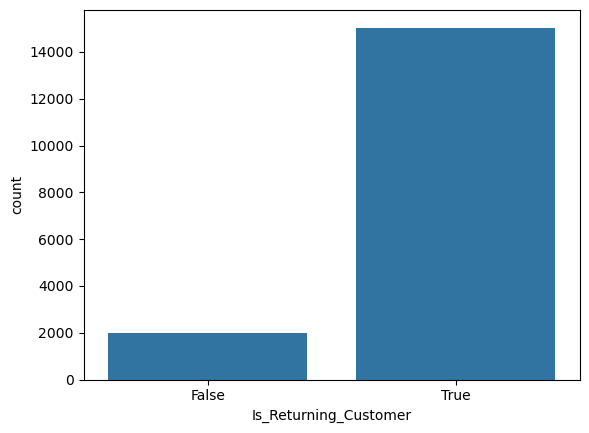

In [21]:
sns.countplot(x='Is_Returning_Customer', data=df)
plt.show()

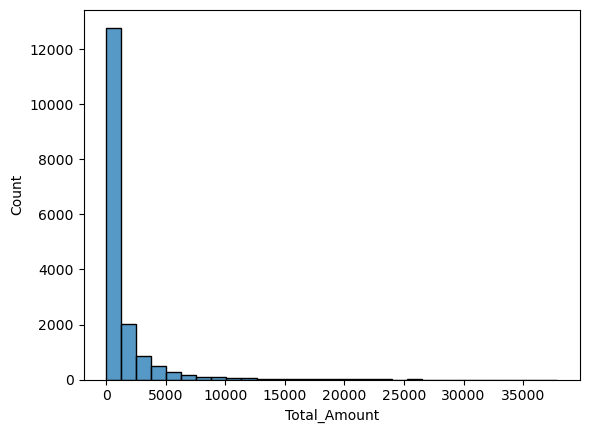

In [20]:
sns.histplot(df['Total_Amount'], bins=30)
plt.show()

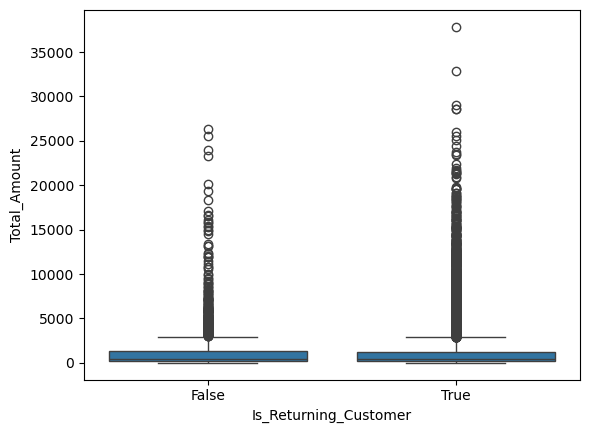

In [19]:
sns.boxplot(x='Is_Returning_Customer', y='Total_Amount', data=df)
plt.show()

## Create Revenue & Discount Features

In [22]:
df['Gross_Amount'] = df['Unit_Price'] * df['Quantity']
df['Discount_Percentage'] = (df['Discount_Amount'] / df['Gross_Amount']) * 100

In [23]:
df[['Gross_Amount', 'Discount_Percentage']].head()

,Gross_Amount,Discount_Percentage
0,29.18,0.000000
1,644.40,21.423029
2,1664.10,0.000000
3,346.50,20.505051
4,534.45,0.000000


## Customer-Level Aggregations

In [24]:
customer_df = df.groupby('Customer_ID').agg({
    'Order_ID': 'count',
    'Total_Amount': 'sum',
    'Session_Duration_Minutes': 'mean',
    'Pages_Viewed': 'mean',
    'Discount_Amount': 'sum',
    'Is_Returning_Customer': 'max',
    'Customer_Rating': 'mean'
}).reset_index()

In [25]:
customer_df.rename(columns={
    'Order_ID': 'Total_Orders',
    'Total_Amount': 'Total_Spend',
    'Session_Duration_Minutes': 'Avg_Session_Duration',
    'Pages_Viewed': 'Avg_Pages_Viewed',
    'Discount_Amount': 'Total_Discount',
    'Customer_Rating': 'Avg_Rating'
}, inplace=True)

In [28]:
customer_df.head()

,Customer_ID,Total_Orders,Total_Spend,Avg_Session_Duration,Avg_Pages_Viewed,Total_Discount,Is_Returning_Customer,Avg_Rating
0,CUST_00001,3,2199.63,14.333333,9.000000,138.05,True,3.333333
1,CUST_00002,2,809.90,15.000000,10.000000,71.05,True,4.000000
2,CUST_00003,2,3030.81,10.500000,8.500000,0.00,True,3.500000
3,CUST_00004,1,383.22,16.000000,15.000000,97.78,False,5.000000
4,CUST_00005,3,2422.73,12.666667,9.333333,0.00,True,3.666667


In [29]:
customer_df.shape

(5000, 8)

## Engagement Score

In [30]:
customer_df['Engagement_Score'] = (
    customer_df['Avg_Session_Duration'] * 0.6 +
    customer_df['Avg_Pages_Viewed'] * 0.4
)

## Check Target Distribution

In [31]:
customer_df['Is_Returning_Customer'].value_counts()

Is_Returning_Customer
True     4651
False     349
Name: count, dtype: int64

# CUSTOMER SEGMENTATION (K-MEANS)

I performed unsupervised customer segmentation and interpreted the segments for business use

1. Segment customers using K-Means
2. Assign each customer a Segment ID
3. Understand what each segment means in business terms
4. Create outputs ready for Power BI animation

### Choose Features for Segmentation

In [32]:
segment_features = customer_df[
    ['Total_Orders', 'Total_Spend',
     'Avg_Session_Duration', 'Avg_Pages_Viewed',
     'Total_Discount', 'Avg_Rating']
]

### Scale the Features
K-Means is distance-based → scaling is non-negotiable.

In [33]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_features = scaler.fit_transform(segment_features)

### Find Optimal Number of Clusters (Elbow Method)

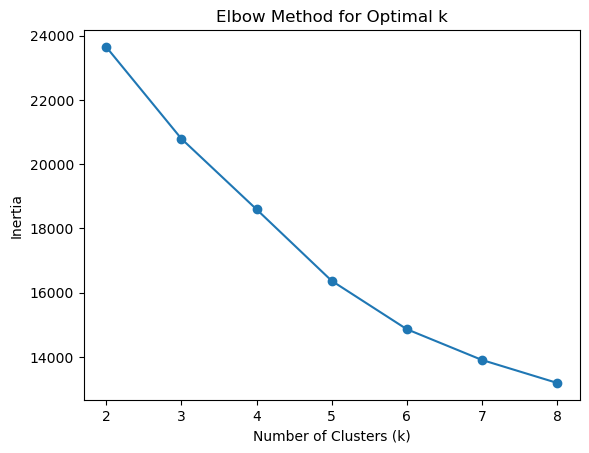

In [36]:
from sklearn.cluster import KMeans

inertia = []

for k in range(2, 9):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)

import matplotlib.pyplot as plt

plt.plot(range(2, 9), inertia, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.show()


## FIT FINAL K-MEANS MODEL

In [39]:
kmeans = KMeans(n_clusters=5, random_state=42)
customer_df['Customer_Segment'] = kmeans.fit_predict(scaled_features)

customer_df[['Customer_ID', 'Customer_Segment']].head()


,Customer_ID,Customer_Segment
0,CUST_00001,2
1,CUST_00002,1
2,CUST_00003,1
3,CUST_00004,1
4,CUST_00005,1


In [40]:
# Segment Size Distribution

customer_df['Customer_Segment'].value_counts().sort_index()

Customer_Segment
0     239
1    1316
2     914
3    1369
4    1162
Name: count, dtype: int64

### Understand Each Segment
#### Create a segment summary table:

In [41]:
segment_summary = customer_df.groupby('Customer_Segment').agg({
    'Total_Orders': 'mean',
    'Total_Spend': 'mean',
    'Avg_Session_Duration': 'mean',
    'Avg_Pages_Viewed': 'mean',
    'Total_Discount': 'mean',
    'Avg_Rating': 'mean'
}).round(2)

segment_summary

,Total_Orders,Total_Spend,Avg_Session_Duration,Avg_Pages_Viewed,Total_Discount,Avg_Rating
Customer_Segment,,,,,,
0,5.94,17156.10,14.54,9.09,1815.50,3.85
1,2.41,2240.54,12.90,9.50,105.75,4.33
2,2.33,2204.90,14.34,8.96,102.16,2.79
3,2.35,2268.40,16.31,8.52,104.34,4.26
4,6.12,8269.77,14.52,8.98,327.47,3.89


# Returning Customer Prediction

##### Prepare Data for ML

In [44]:
X = customer_df[
    ['Total_Orders', 'Total_Spend',
     'Avg_Session_Duration', 'Avg_Pages_Viewed',
     'Total_Discount', 'Avg_Rating']
]

y = customer_df['Is_Returning_Customer']

#Train–Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

#Scale Features

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


### Train FIRST Model (Logistic Regression)

In [45]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(class_weight='balanced', random_state=42)
log_model.fit(X_train_scaled, y_train)


LogisticRegression(class_weight='balanced', random_state=42)

### Evaluate the Model

In [47]:
y_pred = log_model.predict(X_test_scaled)

from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred))
confusion_matrix(y_test, y_pred)


              precision    recall  f1-score   support

       False       0.36      1.00      0.53        70
        True       1.00      0.87      0.93       930

    accuracy                           0.88      1000
   macro avg       0.68      0.93      0.73      1000
weighted avg       0.96      0.88      0.90      1000



array([[ 70,   0],
       [123, 807]])

## RANDOM FOREST
### Train Random Forest Model

In [48]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced'
)

rf_model.fit(X_train, y_train)


RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)

In [50]:
# Predictions

y_pred_rf = rf_model.predict(X_test)

#Evaluate Random Forest

from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred_rf))
confusion_matrix(y_test, y_pred_rf)

              precision    recall  f1-score   support

       False       0.40      0.24      0.30        70
        True       0.94      0.97      0.96       930

    accuracy                           0.92      1000
   macro avg       0.67      0.61      0.63      1000
weighted avg       0.91      0.92      0.91      1000



array([[ 17,  53],
       [ 25, 905]])

# Logistic Regression is the BETTER model for THIS problem.

## Although Random Forest achieved higher accuracy, it failed to identify most non-returning customers. Since the business goal was to detect customers who may leave, I selected Logistic Regression because it successfully identified all at-risk customers.

In [51]:
# Prepare Final Dataset in Python

final_df = customer_df.copy()

# Convert boolean to readable text
final_df['Returning_Status'] = final_df['Is_Returning_Customer'].map({
    True: 'Returning',
    False: 'At Risk'
})

In [52]:
final_df.to_csv("customer_powerbi_data.csv", index=False)